In [1]:
#cell-1
!pip install timm -q

import os, cv2, numpy as np, pandas as pd, torch
import torch.nn as nn, timm
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from sklearn.model_selection import train_test_split
from sklearn.metrics import (roc_auc_score, roc_curve, auc, confusion_matrix,
                              precision_recall_fscore_support, classification_report)
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("✓ Device:", device)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 86.9 MB/s eta 0:00:00:00:01:01
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cuml-cu12 26.2.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cudf-cu12 26.2.1 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which 

In [2]:
#cell-2
BASE_DIR = "/kaggle/input/datasets/organizations/nih-chest-xrays/data/"
CSV_PATH = "/kaggle/input/datasets/organizations/nih-chest-xrays/data/Data_Entry_2017.csv"
IMG_SIZE = 224
BATCH_SIZE = 16

CLASSES = [
    'Atelectasis','Cardiomegaly','Effusion','Infiltration',
    'Mass','Nodule','Pneumonia','Pneumothorax','Consolidation',
    'Edema','Emphysema','Fibrosis','Pleural_Thickening','Hernia'
]

print("Building image index...")
image_dict = {}
for folder in os.listdir(BASE_DIR):
    folder_path = os.path.join(BASE_DIR, folder, "images")
    if os.path.exists(folder_path):
        for fname in os.listdir(folder_path):
            if fname.endswith(".png"):
                image_dict[fname] = os.path.join(folder_path, fname)
print(f"✓ Total images indexed: {len(image_dict)}")

df = pd.read_csv(CSV_PATH)
for cls in CLASSES:
    df[cls] = df["Finding Labels"].apply(lambda x: 1 if cls in str(x) else 0)
df["full_path"] = df["Image Index"].map(image_dict)
df = df[df["full_path"].notna()].reset_index(drop=True)
print(f"✓ Total usable images: {len(df)}")

_, val_df = train_test_split(df, test_size=0.2, random_state=42)
val_df = val_df.reset_index(drop=True)
print(f"✓ Validation images: {len(val_df)}")

class ChestXrayDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df
        self.transform = transform
        self.labels = df[CLASSES].values.astype(np.float32)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_path = self.df.loc[idx, "full_path"]
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        if img is None:
            img = np.zeros((IMG_SIZE, IMG_SIZE), dtype=np.uint8)
        clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
        img = clahe.apply(img)
        img = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)
        img = Image.fromarray(img)
        if self.transform:
            img = self.transform(img)
        label = torch.tensor(self.labels[idx], dtype=torch.float32)
        return img, label

val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

val_loader = DataLoader(
    ChestXrayDataset(val_df, val_transform),
    batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True
)
print(f"✓ Val batches: {len(val_loader)}")

Building image index...
✓ Total images indexed: 112120
✓ Total usable images: 112120
✓ Validation images: 22424
✓ Val batches: 1402


In [3]:
#cell-3
class HybridEfficientNetTransformer(nn.Module):
    def __init__(self, num_classes=14, dropout=0.3):
        super().__init__()
        self.cnn = timm.create_model("efficientnet_b4", pretrained=False, features_only=True)
        with torch.no_grad():
            dummy = torch.randn(1, 3, IMG_SIZE, IMG_SIZE)
            actual_ch = self.cnn(dummy)[-1].shape[1]
        print(f"✓ Detected feature channels: {actual_ch}")

        self.channel_reduce = nn.Sequential(
            nn.Conv2d(actual_ch, 512, kernel_size=1),
            nn.BatchNorm2d(512),
            nn.GELU()
        )
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=512, nhead=8, dim_feedforward=1024,
            dropout=dropout, activation="gelu", batch_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=2)
        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Linear(512, num_classes)

    def forward(self, x):
        features = self.cnn(x)[-1]
        features = self.channel_reduce(features)
        B, C, H, W = features.shape
        tokens = features.flatten(2).permute(0, 2, 1)
        tokens = self.transformer(tokens)
        out = tokens.mean(dim=1)
        out = self.dropout(out)
        out = self.classifier(out)
        return out

print("✓ Model architecture defined")

✓ Model architecture defined


In [4]:
#cell-4
MODEL_PATH = "/kaggle/input/datasets/heysirii/mini-project-hybrid-model-checkpoint/model/best_hybrid_model.pth"

model = HybridEfficientNetTransformer(num_classes=14).to(device)

checkpoint = torch.load(MODEL_PATH, map_location=device)
new_checkpoint = {k.replace("module.", ""): v for k, v in checkpoint.items()}
model.load_state_dict(new_checkpoint)
model.eval()

print("✓ Best model loaded successfully")

✓ Detected feature channels: 448
✓ Best model loaded successfully


In [5]:
!pip install thop -q
import torch, time
from thop import profile  # pip install thop --quiet

model.eval()
dummy = torch.randn(1, 3, 224, 224).to(device)

# FLOPs
flops, params = profile(model, inputs=(dummy,))
print(f"FLOPs: {flops/1e9:.2f} G")

# Latency
with torch.no_grad():
    for _ in range(10):  # warmup
        _ = model(dummy)
    torch.cuda.synchronize()
    start = time.time()
    for _ in range(100):
        _ = model(dummy)
    torch.cuda.synchronize()
    latency = (time.time() - start) / 100 * 1000
print(f"Latency: {latency:.2f} ms")

[INFO] Register count_convNd() for <class 'torch.nn.modules.conv.Conv2d'>.
[INFO] Register zero_ops() for <class 'torch.nn.modules.container.Sequential'>.
[INFO] Register count_normalization() for <class 'torch.nn.modules.batchnorm.BatchNorm2d'>.
[INFO] Register count_linear() for <class 'torch.nn.modules.linear.Linear'>.
[INFO] Register zero_ops() for <class 'torch.nn.modules.dropout.Dropout'>.
[INFO] Register count_normalization() for <class 'torch.nn.modules.normalization.LayerNorm'>.
FLOPs: 1.58 G
Latency: 16.00 ms


tryyyy


In [6]:
!pip install fvcore -q
from fvcore.nn import FlopCountAnalysis, parameter_count_table
import torch

model.eval()

dummy = torch.randn(1, 3, 224, 224).to(device)

flops = FlopCountAnalysis(model, dummy)

print("Total FLOPs:", flops.total() / 1e9, "GFLOPs")
print(parameter_count_table(model))

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 1.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 kB 2.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


Unsupported operator aten::silu_ encountered 95 time(s)
Unsupported operator aten::mean encountered 33 time(s)
Unsupported operator aten::sigmoid encountered 32 time(s)
Unsupported operator aten::mul encountered 40 time(s)
Unsupported operator aten::add encountered 29 time(s)
Unsupported operator aten::gelu encountered 3 time(s)
Unsupported operator aten::div encountered 2 time(s)
Unsupported operator aten::unflatten encountered 2 time(s)
Unsupported operator aten::scaled_dot_product_attention encountered 2 time(s)
The following submodules of the model were never called during the trace of the graph. They may be unused, or they were accessed by direct calls to .forward() or via other python methods. In the latter case they will have zeros for statistics, though their statistics will still contribute to their parent calling module.
transformer.layers.0.self_attn.out_proj, transformer.layers.1.self_attn.out_proj


Total FLOPs: 1.713756128 GFLOPs
| name                       | #elements or shape   |
|:---------------------------|:---------------------|
| model                      | 21.2M                |
|  cnn                       |  16.7M               |
|   cnn.conv_stem            |   1.3K               |
|    cnn.conv_stem.weight    |    (48, 3, 3, 3)     |
|   cnn.bn1                  |   96                 |
|    cnn.bn1.weight          |    (48,)             |
|    cnn.bn1.bias            |    (48,)             |
|   cnn.blocks               |   16.7M              |
|    cnn.blocks.0            |    4.1K              |
|    cnn.blocks.1            |    66.2K             |
|    cnn.blocks.2            |    0.2M              |
|    cnn.blocks.3            |    1.1M              |
|    cnn.blocks.4            |    2.3M              |
|    cnn.blocks.5            |    8.6M              |
|    cnn.blocks.6            |    4.5M              |
|  channel_reduce            |  0.2M              

for paper


In [7]:
import numpy as np
from sklearn.metrics import roc_auc_score
all_labels = np.load('/kaggle/input/datasets/heysirii/eval-predictions/y_true.npy')
all_probs = np.load('/kaggle/input/datasets/heysirii/eval-predictions/y_pred_probs.npy')

n_bootstrap = 1000
ci_results = {}

for i, disease in enumerate(CLASSES):
    y_true = all_labels[:, i]
    y_prob = all_probs[:, i]
    if len(np.unique(y_true)) < 2:
        continue
    boot_aucs = []
    n = len(y_true)
    for _ in range(n_bootstrap):
        idx = np.random.choice(n, n, replace=True)
        if len(np.unique(y_true[idx])) < 2:
            continue
        boot_aucs.append(roc_auc_score(y_true[idx], y_prob[idx]))
    lower = np.percentile(boot_aucs, 2.5)
    upper = np.percentile(boot_aucs, 97.5)
    ci_results[disease] = (lower, upper)
    print(f"{disease:<22} [{lower:.3f}, {upper:.3f}]")

Atelectasis            [0.745, 0.765]
Cardiomegaly           [0.821, 0.853]
Effusion               [0.826, 0.842]
Infiltration           [0.651, 0.671]
Mass                   [0.739, 0.770]
Nodule                 [0.622, 0.654]
Pneumonia              [0.568, 0.634]
Pneumothorax           [0.825, 0.851]
Consolidation          [0.711, 0.745]
Edema                  [0.851, 0.883]
Emphysema              [0.846, 0.883]
Fibrosis               [0.685, 0.737]
Pleural_Thickening     [0.688, 0.730]
Hernia                 [0.776, 0.913]


no need to run cell 5 

In [8]:
#cell-4.1
import numpy as np

CLASSES = [
    'Atelectasis','Cardiomegaly','Effusion','Infiltration',
    'Mass','Nodule','Pneumonia','Pneumothorax','Consolidation',
    'Edema','Emphysema','Fibrosis','Pleural_Thickening','Hernia'
]

all_labels = np.load('/kaggle/input/datasets/heysirii/eval-predictions/y_true.npy')
all_probs = np.load('/kaggle/input/datasets/heysirii/eval-predictions/y_pred_probs.npy')

from sklearn.metrics import roc_auc_score
auc_scores = {}
for i, disease in enumerate(CLASSES):
    y_true = all_labels[:, i]
    y_prob = all_probs[:, i]
    if len(np.unique(y_true)) == 2:
        auc_scores[disease] = roc_auc_score(y_true, y_prob)

print("✓ Reloaded. Shapes:", all_labels.shape, all_probs.shape)
print("Mean AUC:", np.mean(list(auc_scores.values())))

✓ Reloaded. Shapes: (22424, 14) (22424, 14)
Mean AUC: 0.7602070926386386


In [9]:
#cell-4.2
from sklearn.metrics import precision_recall_curve, precision_recall_fscore_support
import pandas as pd

results = []

for i, disease in enumerate(CLASSES):
    y_true = all_labels[:, i]
    y_prob = all_probs[:, i]
    
    precisions, recalls, thresholds = precision_recall_curve(y_true, y_prob)
    f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-8)
    best_idx = np.argmax(f1_scores[:-1])
    best_threshold = thresholds[best_idx]
    
    y_pred = (y_prob >= best_threshold).astype(int)
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average='binary', zero_division=0
    )
    
    results.append({
        'Disease': disease,
        'AUC': round(auc_scores.get(disease, 0), 4),
        'Optimal_Threshold': round(best_threshold, 3),
        'Precision': round(precision, 4),
        'Recall': round(recall, 4),
        'F1-Score': round(f1, 4)
    })

results_df = pd.DataFrame(results).sort_values('AUC', ascending=False)
print(results_df.to_string(index=False))

results_df.to_csv('/kaggle/working/per_class_metrics_optimal.csv', index=False)
print("\n✓ Saved")

           Disease    AUC  Optimal_Threshold  Precision  Recall  F1-Score
             Edema 0.8679              0.512     0.2052  0.3004    0.2439
         Emphysema 0.8651              0.528     0.3275  0.4209    0.3684
            Hernia 0.8408              0.676     0.4474  0.3696    0.4048
      Pneumothorax 0.8379              0.411     0.3834  0.4025    0.3927
      Cardiomegaly 0.8378              0.549     0.2087  0.3285    0.2552
          Effusion 0.8340              0.407     0.3988  0.5962    0.4779
       Atelectasis 0.7551              0.417     0.2571  0.5213    0.3444
              Mass 0.7544              0.501     0.3086  0.2918    0.3000
     Consolidation 0.7285              0.430     0.1240  0.3702    0.1857
          Fibrosis 0.7114              0.446     0.0648  0.1724    0.0942
Pleural_Thickening 0.7088              0.427     0.1433  0.2127    0.1712
      Infiltration 0.6603              0.417     0.3071  0.4822    0.3752
            Nodule 0.6387             

In [10]:
#cell-5
all_probs = []
all_labels = []

print("Running validation inference...")
with torch.no_grad():
    for batch_idx, (images, labels) in enumerate(val_loader):
        images = images.to(device)
        logits = model(images)
        probs = torch.sigmoid(logits).cpu().numpy()
        all_probs.append(probs)
        all_labels.append(labels.cpu().numpy())
        if batch_idx % 200 == 0:
            print(f"Batch {batch_idx}/{len(val_loader)}")

all_probs = np.vstack(all_probs)
all_labels = np.vstack(all_labels)

np.save('/kaggle/working/y_pred_probs.npy', all_probs)
np.save('/kaggle/working/y_true.npy', all_labels)

print("✓ Predictions collected")
print("Probs shape:", all_probs.shape)
print("Labels shape:", all_labels.shape)

Running validation inference...
Batch 0/1402
Batch 200/1402
Batch 400/1402
Batch 600/1402
Batch 800/1402
Batch 1000/1402
Batch 1200/1402
Batch 1400/1402
✓ Predictions collected
Probs shape: (22424, 14)
Labels shape: (22424, 14)


In [11]:
#cell-6
auc_scores = {}
for i, disease in enumerate(CLASSES):
    y_true = all_labels[:, i]
    y_prob = all_probs[:, i]
    if len(np.unique(y_true)) == 2:
        auc_scores[disease] = roc_auc_score(y_true, y_prob)

print("Per-class AUC:")
for disease, a in sorted(auc_scores.items(), key=lambda x: x[1], reverse=True):
    print(f"{disease:<22} {a:.4f}")
print(f"\nMean AUC: {np.mean(list(auc_scores.values())):.4f}")

Per-class AUC:
Edema                  0.8679
Emphysema              0.8651
Hernia                 0.8408
Pneumothorax           0.8379
Cardiomegaly           0.8378
Effusion               0.8340
Atelectasis            0.7551
Mass                   0.7544
Consolidation          0.7285
Fibrosis               0.7114
Pleural_Thickening     0.7088
Infiltration           0.6603
Nodule                 0.6387
Pneumonia              0.6020

Mean AUC: 0.7602


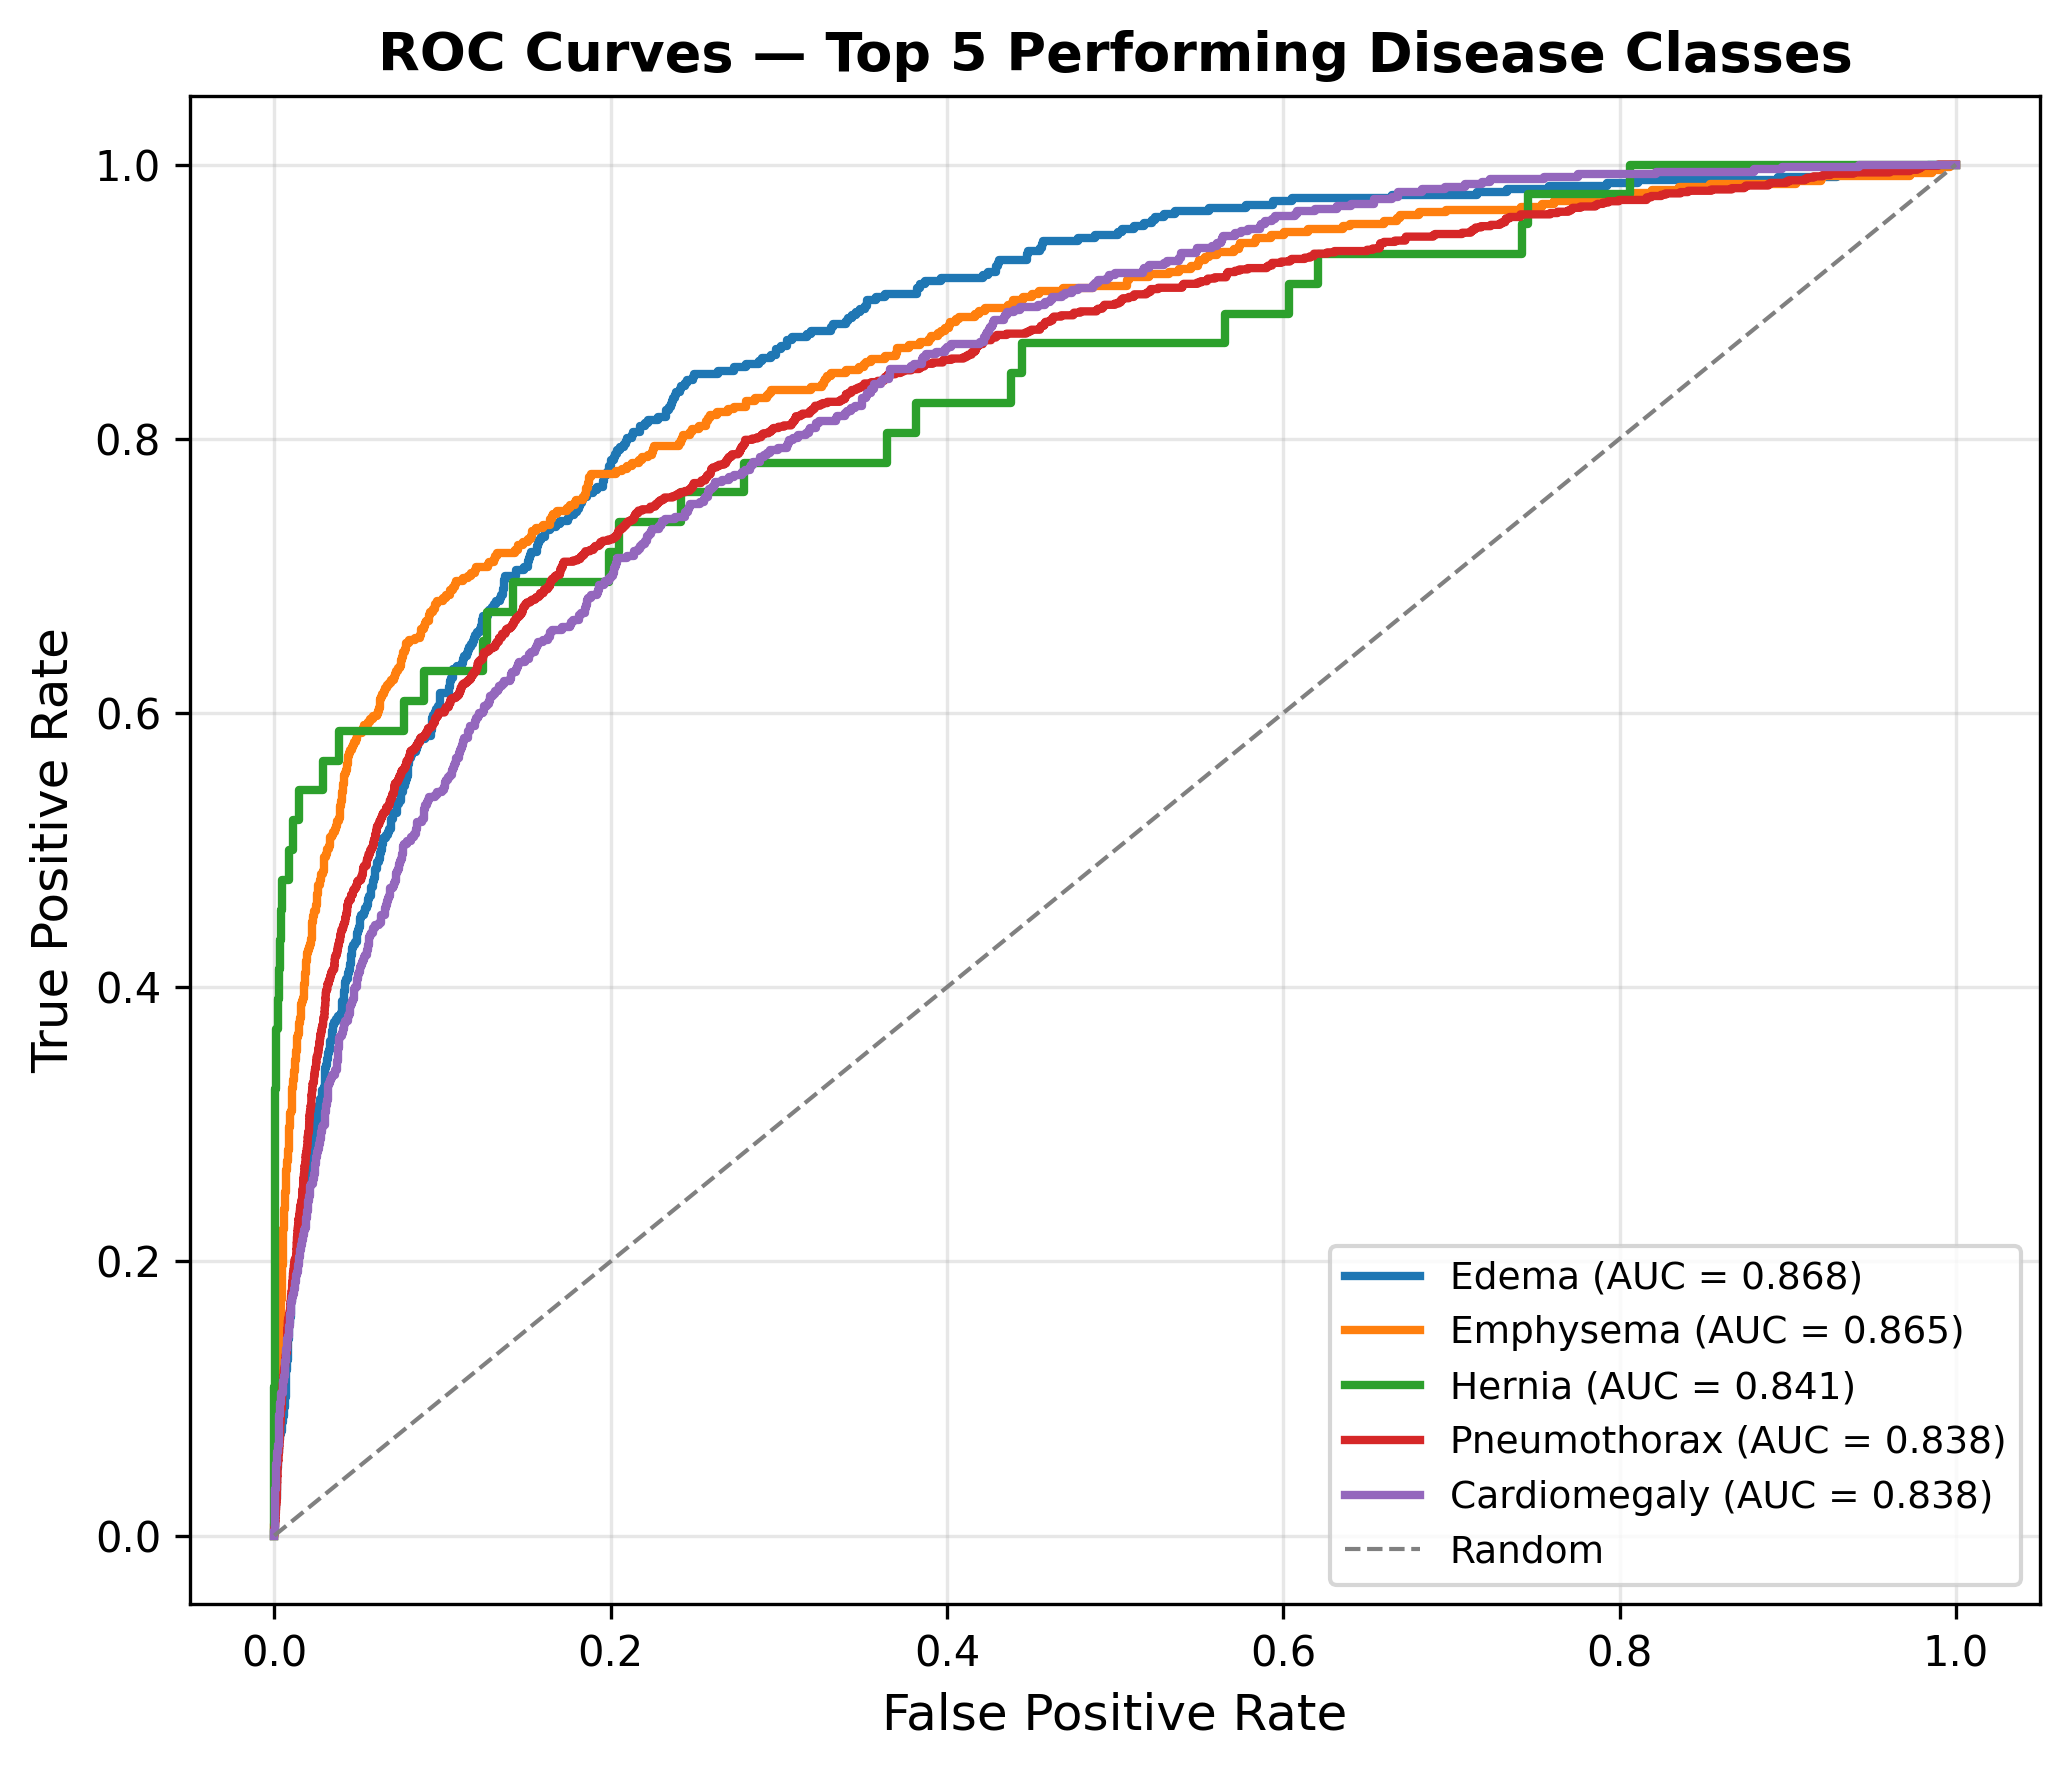

✓ ROC curve saved


In [12]:
#cell-7
OUTPUT_DIR = "/kaggle/working/eval_outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Top 5 classes by AUC, for a readable plot
top5 = sorted(auc_scores, key=auc_scores.get, reverse=True)[:5]

plt.figure(figsize=(7, 6), dpi=300)
for name in top5:
    i = CLASSES.index(name)
    fpr, tpr, _ = roc_curve(all_labels[:, i], all_probs[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, label=f'{name} (AUC = {roc_auc:.3f})')

plt.plot([0, 1], [0, 1], linestyle='--', color='gray', lw=1, label='Random')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curves — Top 5 Performing Disease Classes', fontsize=13, fontweight='bold')
plt.legend(loc='lower right', fontsize=9)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/roc_curve.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ ROC curve saved")

In [13]:
#cell-8
results = []
THRESHOLD = 0.30  # match your demo app threshold

for i, disease in enumerate(CLASSES):
    y_true = all_labels[:, i]
    y_pred = (all_probs[:, i] >= THRESHOLD).astype(int)
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average='binary', zero_division=0
    )
    results.append({
        'Disease': disease,
        'AUC': round(auc_scores.get(disease, 0), 4),
        'Precision': round(precision, 4),
        'Recall': round(recall, 4),
        'F1-Score': round(f1, 4)
    })

results_df = pd.DataFrame(results).sort_values('AUC', ascending=False)
print(results_df.to_string(index=False))

results_df.to_csv(f'{OUTPUT_DIR}/per_class_metrics.csv', index=False)
print("\n✓ Metrics table saved as CSV")

           Disease    AUC  Precision  Recall  F1-Score
             Edema 0.8679     0.0877  0.7063    0.1561
         Emphysema 0.8651     0.0993  0.7228    0.1746
            Hernia 0.8408     0.1549  0.4783    0.2340
      Pneumothorax 0.8379     0.2119  0.6214    0.3161
      Cardiomegaly 0.8378     0.0904  0.6607    0.1591
          Effusion 0.8340     0.2349  0.8526    0.3683
       Atelectasis 0.7551     0.1555  0.8373    0.2623
              Mass 0.7544     0.0857  0.7721    0.1542
     Consolidation 0.7285     0.0654  0.7852    0.1208
          Fibrosis 0.7114     0.0299  0.5141    0.0566
Pleural_Thickening 0.7088     0.0595  0.5445    0.1073
      Infiltration 0.6603     0.1857  0.9509    0.3108
            Nodule 0.6387     0.0721  0.7533    0.1317
         Pneumonia 0.6020     0.0178  0.5136    0.0343

✓ Metrics table saved as CSV


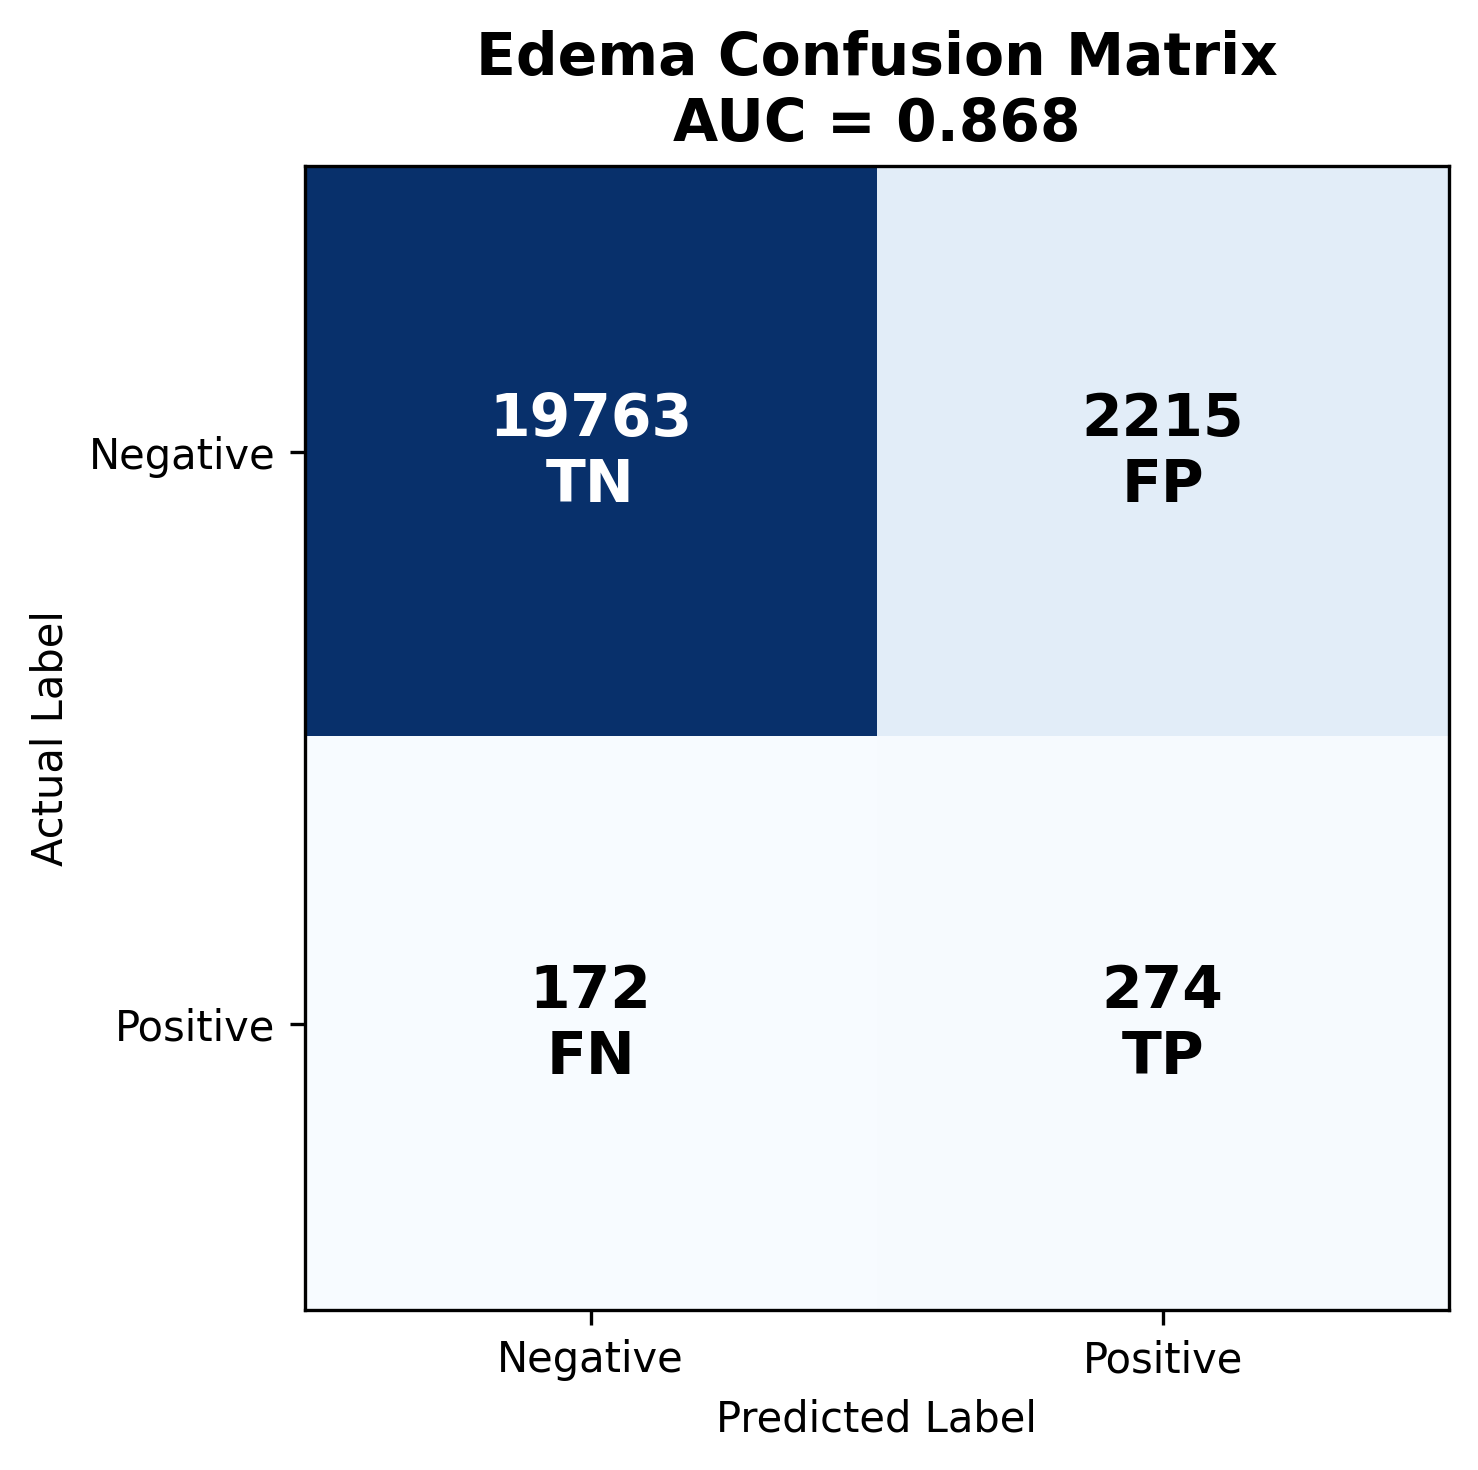

In [14]:
#cell-9
best_disease = max(auc_scores, key=auc_scores.get)
best_idx = CLASSES.index(best_disease)
best_auc = auc_scores[best_disease]

y_true = all_labels[:, best_idx]
y_pred = (all_probs[:, best_idx] >= 0.35).astype(int)
cm = confusion_matrix(y_true, y_pred, labels=[0, 1])

fig, ax = plt.subplots(figsize=(6, 5), dpi=300)
ax.imshow(cm, cmap="Blues")
ax.set_title(f"{best_disease} Confusion Matrix\nAUC = {best_auc:.3f}", fontsize=14, fontweight="bold")
ax.set_xlabel("Predicted Label"); ax.set_ylabel("Actual Label")
ax.set_xticks([0,1]); ax.set_yticks([0,1])
ax.set_xticklabels(["Negative","Positive"]); ax.set_yticklabels(["Negative","Positive"])
cell_names = [["TN","FP"],["FN","TP"]]
for i in range(2):
    for j in range(2):
        v = cm[i,j]
        ax.text(j, i, f"{v}\n{cell_names[i][j]}", ha="center", va="center",
                 color="white" if v > cm.max()/2 else "black", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/best_class_confusion_matrix_{best_disease}.png', dpi=300, bbox_inches="tight")
plt.show()

In [15]:
#cell-10
from sklearn.metrics import precision_recall_curve

results = []

for i, disease in enumerate(CLASSES):
    y_true = all_labels[:, i]
    y_prob = all_probs[:, i]
    
    # Find threshold that maximizes F1 for this class
    precisions, recalls, thresholds = precision_recall_curve(y_true, y_prob)
    f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-8)
    best_idx = np.argmax(f1_scores[:-1])  # last point has no threshold
    best_threshold = thresholds[best_idx]
    
    y_pred = (y_prob >= best_threshold).astype(int)
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average='binary', zero_division=0
    )
    
    results.append({
        'Disease': disease,
        'AUC': round(auc_scores.get(disease, 0), 4),
        'Optimal_Threshold': round(best_threshold, 3),
        'Precision': round(precision, 4),
        'Recall': round(recall, 4),
        'F1-Score': round(f1, 4)
    })

results_df = pd.DataFrame(results).sort_values('AUC', ascending=False)
print(results_df.to_string(index=False))
results_df.to_csv('/kaggle/working/eval_outputs/per_class_metrics_optimal.csv', index=False)

           Disease    AUC  Optimal_Threshold  Precision  Recall  F1-Score
             Edema 0.8679              0.512     0.2052  0.3004    0.2439
         Emphysema 0.8651              0.528     0.3275  0.4209    0.3684
            Hernia 0.8408              0.676     0.4474  0.3696    0.4048
      Pneumothorax 0.8379              0.411     0.3834  0.4025    0.3927
      Cardiomegaly 0.8378              0.549     0.2087  0.3285    0.2552
          Effusion 0.8340              0.407     0.3988  0.5962    0.4779
       Atelectasis 0.7551              0.417     0.2571  0.5213    0.3444
              Mass 0.7544              0.501     0.3086  0.2918    0.3000
     Consolidation 0.7285              0.430     0.1240  0.3702    0.1857
          Fibrosis 0.7114              0.446     0.0648  0.1724    0.0942
Pleural_Thickening 0.7088              0.427     0.1433  0.2127    0.1712
      Infiltration 0.6603              0.417     0.3071  0.4822    0.3752
            Nodule 0.6387             